# FIGURE 1 — VITESSES EN SITE (v_mean) EN FONCTION DE l

*(cellule indépendante : librairies, chemin, filtres et données rechargés ici)*

In [2]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-30")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
mu    = 150
theta = 100
s_selected = 35

alphad_periodic = 0.0    # PERIODIC
alphad_homogen  = 1.0    # HOMOGEN (= periodic avec alphad = 1.0)
bpmin_random    = 0      # RANDOM

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────
ARRAY_COLS = ["results", "results_mean", "alpha_mean_a"]

df_data = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("s")     == s_selected)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

# ─────────────────────────────────────────────
# SOUS-ENSEMBLES : PERIODIC / HOMOGEN / RANDOM
#
# NB : alphad est un flottant lu depuis du parquet -> sa représentation
# binaire n'est pas exactement 0.30 (ex : 0.29999999999999993 ou
# 0.30000000000000004). On arrondit donc à 3 décimales avant de filtrer,
# pour ne JAMAIS comparer deux floats avec une égalité stricte non protégée.
# ─────────────────────────────────────────────
df_periodic = (
    df_data
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_periodic)
)

df_homogen = (
    df_data
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_homogen)
)

df_random = (
    df_data
    .filter(pl.col("land") == "random")
    .with_columns(pl.col("bpmin").round(3))
    .filter(pl.col("bpmin") == bpmin_random)
)

def density(l):
    return (150 + l) / (35 + l)

# ─────────────────────────────────────────────
# FIGURE - VITESSES EN SITE (v_mean vs l)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=1200)

# PERIODIC (alphad = 0)
l_periodic = df_periodic["l"].to_numpy()
v_periodic = df_periodic["v_mean"].to_numpy()
ax.plot(l_periodic, v_periodic, ls="-", alpha=0.75, label="Periodic")

# RANDOM (bpmin = 0)
l_random = df_random["l"].to_numpy()
v_random = df_random["v_mean"].to_numpy()
ax.plot(l_random, v_random, ls="-", alpha=0.75, label="Random")

# HOMOGEN (alphad = 1.0, equivalent periodique homogene)
l_homogen = df_homogen["l"].to_numpy()
v_homogen = mu / density(l_homogen)
ax.plot(l_homogen, v_homogen, ls="-", alpha=0.75, label="Homogen")

ax.axhline(mu, c="k", ls="--", label=r"$v=\mu$")

ax.set_xlabel(r"$<l>$")
ax.set_ylabel(r"$v_{mean}$")
ax.legend(loc="best")
ax.grid(True, alpha=0.30, which="both")

plt.tight_layout()
plt.show()


ComputeError: failed to retrieve first file schema (parquet): empty input: paths: []. Hint: passing a schema can allow this scan to succeed with an empty DataFrame.

# FIGURE 2 — COMPACTION EN FONCTION DE l_mean

*(cellule indépendante)*

In [ ]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16

def density(l):
    return (150 + l) / (35 + l)

# ─────────────────────────────────────────────
# FIGURE - COMPACTION vs l_mean
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=1200)

l_mean = np.arange(0, 500, 1)
ax.plot(l_mean, density(l_mean), ls="-", alpha=1)

ax.set_xlabel(r"$<l>$")
ax.set_ylabel(r"$\overline{c}$")
ax.grid(True, alpha=0.30)

plt.tight_layout()
plt.show()


# FIGURE 5.C

*(cellule indépendante — alphad = 0.30 affiché correctement malgré l'imprécision binaire des flottants)*

In [ ]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import numpy as np
from pathlib import Path

plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-30")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
mu    = 150
theta = 100

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────
ARRAY_COLS = []

df_data = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu) &
        (pl.col("theta") == theta)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

df_periodic = df_data.filter(pl.col("land") == "periodic")
df_random   = df_data.filter(pl.col("land") == "random")

# ─────────────────────────────────────────────
# FIGURE - 5.C
# ─────────────────────────────────────────────
v_to_plot = "vc_mean"

fig, ax = plt.subplots(figsize=(8, 6), dpi=1200)

# Valeurs cibles d'alphad / bpmin à tracer.
alphads_target = np.array([0.0, 0.30])
bpmins_target  = np.array([0, 20])

# ── Main ──────────────────────────────────────
#
# IMPORTANT : alphad est un flottant lu depuis du parquet. 0.30 n'a pas de
# représentation binaire exacte (il vaut en mémoire un truc du type
# 0.29999999999999998889776975... ou 0.30000000000000004440892...).
# Une comparaison stricte `alphad in alphads_target` peut donc échouer en
# silence et faire disparaître la courbe correspondante, alors qu'on a bien
# les bonnes données en base. On compare ici avec une tolérance (np.isclose)
# et on affiche le label arrondi à 2 décimales pour garantir un "0.30"
# propre dans la légende.

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad = group["alphad"][0]
    l_mean = group["l_mean"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    if np.any(np.isclose(alphad, alphads_target, atol=1e-6)):
        ax.plot(l_mean, vc, marker="s", ls="-", alpha=0.75,
                 label=f"Periodic : alphad = {alphad:.2f}")

for group in df_random.partition_by("bpmin", as_dict=False):
    bpmin  = group["bpmin"][0]
    l_mean = group["l"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    if np.any(np.isclose(bpmin, bpmins_target, atol=1e-6)):
        ax.plot(l_mean, vc, marker="o", ls="-", alpha=0.75,
                 label=f"Random : bpmin = {bpmin}")

ax.axhline(mu, c="k", ls="--", label=r"$v = \mu * \overline{c}$")
ax.set_xlim([0, 500])
ax.set_xlabel(r"$<l>$")
ax.set_ylabel(r"$v^{bp}_{mean}$")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.30)
plt.tight_layout()
plt.show()


# FIGURE RECAPITULATIVE — FIG.1 / FIG.2 (gauche) + FIG.5.C (droite)

*(cellule indépendante — pur affichage : mêmes données, mêmes courbes, même taille de police partout)*

In [3]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import numpy as np
from pathlib import Path

# Taille de police UNIQUE pour toute la figure (titres, labels, ticks,
# legendes) : on garde exactement la même valeur que dans les figures
# individuelles, donc rien n'est redéfini case par case ci-dessous.
plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-30")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
mu    = 150
theta = 100
s_selected = 35

alphad_periodic = 0.0    # PERIODIC
alphad_homogen  = 1.0    # HOMOGEN (= periodic avec alphad = 1.0)
bpmin_random    = 0      # RANDOM

xlims=[-10, 510]
ylims=[0, 160]


# ─────────────────────────────────────────────
# FONCTIONS
# ─────────────────────────────────────────────

def density(l):
    return (150 + l) / (35 + l)

def compaction(l):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    return ((l * cl + s * cn) / (l + s))

def th_speed_sites(l):
    s = 35
    mu = 150
    return (mu * (l / (l+s)))

def th_speed_bps(l):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    mu = 150
    return (th_speed_sites(l) * (l * cl + s * cn) / (l + s))


# ─────────────────────────────────────────────
# CIBLES UTILISEES A DROITE (ax3)
# ─────────────────────────────────────────────
# NB : il faut les definir AVANT de construire les colormaps/nuances,
# puisque ces dernieres dependent de len(alphads_target)/len(bpmins_target).
v_to_plot      = "vc_mean"
alphads_target = np.array([0.0, 0.30])
bpmins_target  = np.array([0, 20])


# ─────────────────────────────────────────────
# COULEURS COHERENTES ENTRE LES SOUS-FIGURES
# ─────────────────────────────────────────────
# Objectif : la FAMILLE (Periodic vs Random) porte la meme teinte en haut
# a gauche (ax1) et a droite (ax3), sans rien changer au reste du code
# (memes donnees, memes filtres, memes labels, meme mise en page).
#
# A droite (ax3), chaque famille comporte en plus PLUSIEURS variantes
# (alphad pour Periodic, bpmin pour Random) qui doivent rester
# visuellement distinguables : on degrade donc la teinte (clair -> fonce)
# selon la variante, via deux colormaps dedies (Blues pour Periodic,
# Oranges pour Random).
#
# IMPORTANT (fix) : pour ax1, qui n'affiche qu'une seule courbe par
# famille (celle correspondant a alphad_periodic / bpmin_random), il faut
# reprendre EXACTEMENT la meme nuance que celle attribuee a ce cas precis
# dans ax3 -- et non une nuance fixe arbitraire (ex: "la plus foncee"),
# qui ne correspond au bon cas que si celui-ci se trouve etre en derniere
# position dans alphads_target / bpmins_target. On retrouve donc d'abord
# l'index de alphad_periodic dans alphads_target (et de bpmin_random dans
# bpmins_target), puis on prend la nuance a cet index dans shades_periodic
# / shades_random.
cmap_periodic = plt.cm.Blues
cmap_random   = plt.cm.Oranges
color_homogen = "black"

# Nuances utilisees a droite (ax3), une par variante, du plus clair (premiere
# valeur de la liste cible) au plus fonce (derniere valeur de la liste cible).
shades_periodic = [cmap_periodic(x) for x in np.linspace(0.45, 0.95, len(alphads_target))]
shades_random   = [cmap_random(x)   for x in np.linspace(0.45, 0.95, len(bpmins_target))]

# Index du cas affiche a gauche (ax1) au sein des listes cibles de droite (ax3).
idx_periodic_left = int(np.argmax(np.isclose(alphad_periodic, alphads_target, atol=1e-6)))
idx_random_left   = int(np.argmax(np.isclose(bpmin_random,    bpmins_target,  atol=1e-6)))

# Couleurs utilisees a gauche (ax1) : memes nuances que le cas correspondant a droite.
color_periodic = shades_periodic[idx_periodic_left]
color_random   = shades_random[idx_random_left]

# ─────────────────────────────────────────────
# DONNEES POUR FIG.1 ET FIG.2 (filtre sur s_selected)
# ─────────────────────────────────────────────
ARRAY_COLS_12 = ["results", "results_mean", "alpha_mean_a"]

df_data_12 = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("s")     == s_selected)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS_12))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

# NB : alphad/bpmin sont des flottants issus de parquet -> on arrondit avant
# de filtrer pour ne jamais comparer deux floats avec une égalité stricte
# non protégée (cf. figures précédentes).
df_periodic_12 = (
    df_data_12
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_periodic)
)

df_homogen_12 = (
    df_data_12
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_homogen)
)

df_random_12 = (
    df_data_12
    .filter(pl.col("land") == "random")
    .with_columns(pl.col("bpmin").round(3))
    .filter(pl.col("bpmin") == bpmin_random)
)

# ─────────────────────────────────────────────
# DONNEES POUR FIG.5.C (pas de filtre sur s)
# ─────────────────────────────────────────────
df_data_5c = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu) &
        (pl.col("theta") == theta)
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

df_periodic_5c = df_data_5c.filter(pl.col("land") == "periodic")
df_random_5c   = df_data_5c.filter(pl.col("land") == "random")

# ─────────────────────────────────────────────
# MISE EN PAGE : grille 2x2
#   - FIG.1 -> en haut a gauche
#   - FIG.2 -> en bas a gauche
#   - FIG.5.C -> a droite, sur les 2 lignes (donc 2 carres de haut)
# Resultat : 2 carres empiles a gauche + 1 grand carre/rectangle a droite.
# Chaque sous-figure garde le meme rapport largeur/hauteur qu'un carre
# individuel (8x6 -> ici 8x8 pour rester proche d'un carre), et la taille
# de police est identique partout puisqu'on ne touche a aucun fontsize
# local : tout vient du rcParams global defini plus haut.
# ─────────────────────────────────────────────


fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 1],
    height_ratios=[1, 1]
)

ax1 = fig.add_subplot(gs[0, 0])      # Fig.1
ax2 = fig.add_subplot(gs[1, 0])      # Fig.2
ax3 = fig.add_subplot(gs[:, 1:])     # grand carré (2 colonnes × 2 lignes)

# ── FIG.1 : VITESSES EN SITE (v_mean vs l) ─────
ax1.axhline(mu, c="k", ls="--", label=r"$v=\mu$")

l_homogen = np.arange(10,450,1)
v_homogen_sites = th_speed_sites(l_homogen)
ax1.plot(l_homogen, v_homogen_sites, ls="-", alpha=0.75, label="Homogen", color=color_homogen)

l_periodic = df_periodic_12["l"].to_numpy()
v_periodic = df_periodic_12["v_mean"].to_numpy()
ax1.plot(l_periodic, v_periodic, ls="-", lw=2, alpha=0.75, marker="s", label="Periodic", color=color_periodic)

l_random = df_random_12["l"].to_numpy()
v_random = df_random_12["v_mean"].to_numpy()
ax1.plot(l_random, v_random, ls="-", lw=2, alpha=0.75, marker="o", label="Random", color=color_random)

ax1.set_xlabel(r"$<l>$")
ax1.set_ylabel(r"$v_{\text{mean}}$")
ax1.set_xlim(xlims)
ax1.set_ylim(ylims)
ax1.legend(loc="best")
ax1.grid(True, alpha=0.30, which="both")

# ── FIG.2 : COMPACTION vs l_mean ───────────────
l_mean_curve = np.arange(0, 500, 1)
ax2.plot(l_mean_curve, density(l_mean_curve), ls="-", alpha=1, lw=2, color="slategray")
ax2.set_xlabel(r"$<l>$")
ax2.set_ylabel(r"$\overline{c}$")
ax2.set_xlim(xlims)
ax2.grid(True, alpha=0.30)

# ── FIG.5.C ─────────────────────────────────────
ax3.axhline(mu, c="k", ls="--", label=r"$v = \mu * c_{l}$")

l_homogen = np.arange(10,450,1)
v_homogen_bps = th_speed_bps(l_homogen)
ax3.plot(l_homogen, v_homogen_bps, ls="-", alpha=0.75, label="Homogen", color=color_homogen)

for group in df_periodic_5c.partition_by("alphad", as_dict=False):
    alphad = group["alphad"][0]
    # l_mean = group["l_mean"].to_numpy()
    l      = group["l"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    match  = np.isclose(alphad, alphads_target, atol=1e-6)
    if np.any(match):
        idx = int(np.argmax(match))   # position de cette variante dans alphads_target -> nuance associee
        ax3.plot(l, vc, ls="-", lw=2, alpha=0.75, marker="s",
                  label=rf"Periodic : $\alpha_{{d}} = {alphad:.2f}$", color=shades_periodic[idx])

for group in df_random_5c.partition_by("bpmin", as_dict=False):
    bpmin  = group["bpmin"][0]
    l_mean = group["l"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    match  = np.isclose(bpmin, bpmins_target, atol=1e-6)
    if np.any(match):
        idx = int(np.argmax(match))   # position de cette variante dans bpmins_target -> nuance associee
        ax3.plot(l_mean, vc, ls="-", lw=2, alpha=0.75, marker="o",
                  label=rf"Random : $bp_{{\min}} = {bpmin}$", color=shades_random[idx])

ax3.set_xlabel(r"$<l>$")
ax3.set_ylabel(r"$v^{\text{bp}}_{\text{mean}}$")
ax3.legend(loc="lower right")
ax3.set_xlim(xlims)
ax3.grid(True, alpha=0.30)

# fig.text(0.005, 0.97, "A", fontsize=28, fontweight="bold")
# fig.text(0.005, 0.475, "B", fontsize=28, fontweight="bold") 
# fig.text(0.365, 0.97, "C", fontsize=28, fontweight="bold")
for ax, letter in zip(
    [ax1, ax2, ax3],
    ["A", "B", "C"],
):
    ax.set_title(letter, loc="left", fontweight="bold", fontsize=20)

plt.tight_layout()
plt.savefig("fig5_final.png", bbox_inches="tight", dpi=300)
plt.show()

ComputeError: failed to retrieve first file schema (parquet): empty input: paths: []. Hint: passing a schema can allow this scan to succeed with an empty DataFrame.

In [ ]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import numpy as np
from pathlib import Path

# Taille de police UNIQUE pour toute la figure (titres, labels, ticks,
# legendes) : on garde exactement la même valeur que dans les figures
# individuelles, donc rien n'est redéfini case par case ci-dessous.
plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-30")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
mu    = 150
theta = 100
s_selected = 35

alphad_periodic = 0.0    # PERIODIC
alphad_homogen  = 1.0    # HOMOGEN (= periodic avec alphad = 1.0)
bpmin_random    = 0      # RANDOM

xlims=[-10, 510]
ylims=[0, 160]


# ─────────────────────────────────────────────
# FONCTIONS
# ─────────────────────────────────────────────

def density(l):
    return (150 + l) / (35 + l)

def compaction(l):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    return ((l * cl + s * cn) / (l + s))

def th_speed_sites(l):
    s = 35
    mu = 150
    return (mu * (l / (l+s)))

def th_speed_bps(l):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    mu = 150
    return (th_speed_sites(l) * (l * cl + s * cn) / (l + s))


# ─────────────────────────────────────────────
# CIBLES UTILISEES A DROITE (ax3)
# ─────────────────────────────────────────────
# NB : il faut les definir AVANT de construire les colormaps/nuances,
# puisque ces dernieres dependent de len(alphads_target)/len(bpmins_target).
v_to_plot      = "vc_mean"
alphads_target = np.array([0.0, 0.30])
bpmins_target  = np.array([0, 20])


# ─────────────────────────────────────────────
# COULEURS COHERENTES ENTRE LES SOUS-FIGURES
# ─────────────────────────────────────────────
# Objectif : la FAMILLE (Periodic vs Random) porte la meme teinte en haut
# a gauche (ax1) et a droite (ax3), sans rien changer au reste du code
# (memes donnees, memes filtres, memes labels, meme mise en page).
#
# A droite (ax3), chaque famille comporte en plus PLUSIEURS variantes
# (alphad pour Periodic, bpmin pour Random) qui doivent rester
# visuellement distinguables : on degrade donc la teinte (clair -> fonce)
# selon la variante, via deux colormaps dedies (Blues pour Periodic,
# Oranges pour Random).
#
# IMPORTANT (fix) : pour ax1, qui n'affiche qu'une seule courbe par
# famille (celle correspondant a alphad_periodic / bpmin_random), il faut
# reprendre EXACTEMENT la meme nuance que celle attribuee a ce cas precis
# dans ax3 -- et non une nuance fixe arbitraire (ex: "la plus foncee"),
# qui ne correspond au bon cas que si celui-ci se trouve etre en derniere
# position dans alphads_target / bpmins_target. On retrouve donc d'abord
# l'index de alphad_periodic dans alphads_target (et de bpmin_random dans
# bpmins_target), puis on prend la nuance a cet index dans shades_periodic
# / shades_random.
cmap_periodic = plt.cm.Blues
cmap_random   = plt.cm.Oranges
color_homogen = "black"

# Nuances utilisees a droite (ax3), une par variante, du plus clair (premiere
# valeur de la liste cible) au plus fonce (derniere valeur de la liste cible).
shades_periodic = [cmap_periodic(x) for x in np.linspace(0.45, 0.95, len(alphads_target))]
shades_random   = [cmap_random(x)   for x in np.linspace(0.45, 0.95, len(bpmins_target))]

# Index du cas affiche a gauche (ax1) au sein des listes cibles de droite (ax3).
idx_periodic_left = int(np.argmax(np.isclose(alphad_periodic, alphads_target, atol=1e-6)))
idx_random_left   = int(np.argmax(np.isclose(bpmin_random,    bpmins_target,  atol=1e-6)))

# Couleurs utilisees a gauche (ax1) : memes nuances que le cas correspondant a droite.
color_periodic = shades_periodic[idx_periodic_left]
color_random   = shades_random[idx_random_left]

# ─────────────────────────────────────────────
# DONNEES POUR FIG.1 ET FIG.2 (filtre sur s_selected)
# ─────────────────────────────────────────────
ARRAY_COLS_12 = ["results", "results_mean", "alpha_mean_a"]

df_data_12 = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("s")     == s_selected)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS_12))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

# NB : alphad/bpmin sont des flottants issus de parquet -> on arrondit avant
# de filtrer pour ne jamais comparer deux floats avec une égalité stricte
# non protégée (cf. figures précédentes).
df_periodic_12 = (
    df_data_12
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_periodic)
)

df_homogen_12 = (
    df_data_12
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad") == alphad_homogen)
)

df_random_12 = (
    df_data_12
    .filter(pl.col("land") == "random")
    .with_columns(pl.col("bpmin").round(3))
    .filter(pl.col("bpmin") == bpmin_random)
)

# ─────────────────────────────────────────────
# DONNEES POUR FIG.5.C (pas de filtre sur s)
# ─────────────────────────────────────────────
df_data_5c = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu) &
        (pl.col("theta") == theta)
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

df_periodic_5c = df_data_5c.filter(pl.col("land") == "periodic")
df_random_5c   = df_data_5c.filter(pl.col("land") == "random")

# ─────────────────────────────────────────────
# MISE EN PAGE : grille 2x2
#   - FIG.1 -> en haut a gauche
#   - FIG.2 -> en bas a gauche
#   - FIG.5.C -> a droite, sur les 2 lignes (donc 2 carres de haut)
# Resultat : 2 carres empiles a gauche + 1 grand carre/rectangle a droite.
# Chaque sous-figure garde le meme rapport largeur/hauteur qu'un carre
# individuel (8x6 -> ici 8x8 pour rester proche d'un carre), et la taille
# de police est identique partout puisqu'on ne touche a aucun fontsize
# local : tout vient du rcParams global defini plus haut.
# ─────────────────────────────────────────────


fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 1],
    height_ratios=[1, 1]
)

ax1 = fig.add_subplot(gs[0, 0])      # Fig.1
ax2 = fig.add_subplot(gs[1, 0])      # Fig.2
ax3 = fig.add_subplot(gs[:, 1:])     # grand carré (2 colonnes × 2 lignes)

# ── FIG.1 : VITESSES EN SITE (v_mean vs l) ─────



mu = 150
theta = 100
s = 35
bpmin = 0
alphad = 0

df_data_0 = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("bpmin") == bpmin) &
        (pl.col("alphad") == alphad) &
        (pl.col("s")     == s)
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)


df_periodic_0 = df_data_0.filter(
    pl.col("land") == "periodic"
)
df_random_0 = df_data_0.filter(
    pl.col("land") == "random"
)

plt.figure(figsize=(8,6), dpi=300)



plt.axhline(mu, c="k", ls="--", label=r"$v=\mu$")

l_homogen = np.arange(10,450,1)
v_homogen_sites = th_speed_sites(l_homogen, 150)
plt.plot(l_homogen, v_homogen_sites, ls="-", alpha=0.75, label="Homogen", color="k")

l_periodic = df_periodic_0["l"].to_numpy()
v_periodic = df_periodic_0["v_mean"].to_numpy()
plt.plot(l_periodic, v_periodic, ls="-", lw=2, alpha=0.75, marker="s", label="Periodic")

l_random = df_random_0["l"].to_numpy()
v_random = df_random_0["v_mean"].to_numpy()
plt.plot(l_random, v_random, ls="-", lw=2, alpha=0.75, marker="o", label="Random")

plt.xlabel(r"$\bar{l}$")
plt.ylabel(r"$v_{\text{mean}}$")
plt.xlim(xlim_main)
plt.ylim(ylim_main)
plt.legend(loc="best")
plt.grid(True, alpha=0.30, which="both")
plt.show()






ax1.axhline(mu, c="k", ls="--", label=r"$v=\mu$")

l_homogen = np.arange(10,450,1)
v_homogen_sites = th_speed_sites(l_homogen)
ax1.plot(l_homogen, v_homogen_sites, ls="-", alpha=0.75, label="Homogen", color=color_homogen)

l_periodic = df_periodic_12["l"].to_numpy()
v_periodic = df_periodic_12["v_mean"].to_numpy()
ax1.plot(l_periodic, v_periodic, ls="-", lw=2, alpha=0.75, marker="s", label="Periodic", color=color_periodic)

l_random = df_random_12["l"].to_numpy()
v_random = df_random_12["v_mean"].to_numpy()
ax1.plot(l_random, v_random, ls="-", lw=2, alpha=0.75, marker="o", label="Random", color=color_random)

ax1.set_xlabel(r"$<l>$")
ax1.set_ylabel(r"$v_{\text{mean}}$")
ax1.set_xlim(xlims)
ax1.set_ylim(ylims)
ax1.legend(loc="best")
ax1.grid(True, alpha=0.30, which="both")

# ── FIG.2 : COMPACTION vs l_mean ───────────────
l_mean_curve = np.arange(0, 500, 1)
ax2.plot(l_mean_curve, density(l_mean_curve), ls="-", alpha=1, lw=2, color="slategray")
ax2.set_xlabel(r"$<l>$")
ax2.set_ylabel(r"$\overline{c}$")
ax2.set_xlim(xlims)
ax2.grid(True, alpha=0.30)

# ── FIG.5.C ─────────────────────────────────────
ax3.axhline(mu, c="k", ls="--", label=r"$v = \mu * c_{l}$")

l_homogen = np.arange(10,450,1)
v_homogen_bps = th_speed_bps(l_homogen)
ax3.plot(l_homogen, v_homogen_bps, ls="-", alpha=0.75, label="Homogen", color=color_homogen)

for group in df_periodic_5c.partition_by("alphad", as_dict=False):
    alphad = group["alphad"][0]
    # l_mean = group["l_mean"].to_numpy()
    l      = group["l"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    match  = np.isclose(alphad, alphads_target, atol=1e-6)
    if np.any(match):
        idx = int(np.argmax(match))   # position de cette variante dans alphads_target -> nuance associee
        ax3.plot(l, vc, ls="-", lw=2, alpha=0.75, marker="s",
                  label=rf"Periodic : $\alpha_{{d}} = {alphad:.2f}$", color=shades_periodic[idx])

for group in df_random_5c.partition_by("bpmin", as_dict=False):
    bpmin  = group["bpmin"][0]
    l_mean = group["l"].to_numpy()
    vc     = group[v_to_plot].to_numpy()
    match  = np.isclose(bpmin, bpmins_target, atol=1e-6)
    if np.any(match):
        idx = int(np.argmax(match))   # position de cette variante dans bpmins_target -> nuance associee
        ax3.plot(l_mean, vc, ls="-", lw=2, alpha=0.75, marker="o",
                  label=rf"Random : $bp_{{\min}} = {bpmin}$", color=shades_random[idx])

ax3.set_xlabel(r"$<l>(bp)$")
ax3.set_ylabel(r"$v^{\text{bp}}_{\text{mean}}$")
ax3.legend(loc="lower right")
ax3.set_xlim(xlims)
ax3.grid(True, alpha=0.30)

# fig.text(0.005, 0.97, "A", fontsize=28, fontweight="bold")
# fig.text(0.005, 0.475, "B", fontsize=28, fontweight="bold") 
# fig.text(0.365, 0.97, "C", fontsize=28, fontweight="bold")
# for ax, letter in zip(
#     [ax1, ax2, ax3],
#     ["A", "B", "C"],
# ):
#     ax.set_title(letter, loc="left", fontweight="bold", fontsize=20)

plt.tight_layout()
plt.savefig("fig5_final.png", bbox_inches="tight", dpi=300)
plt.show()

Unique values of algo : ['1S']
Unique values of fact : [False]
Unique values of mode : ['none']
Unique values of dstr : [ True]
Unique values of land : ['periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360
 370 380 390 400 410 420 430 440 450]
Unique values of bpmin : [ 0  5 10 15 20]
Unique values of mu : [150 500]
Unique values of theta : [ 50 100 300]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [2.]
Unique values of alphac : [1.]
Unique values of alphad : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of alphar : [0.]
Unique values of krel : [0.]
Unique values of Kp : [0.]
Unique values of Kz : [0.]


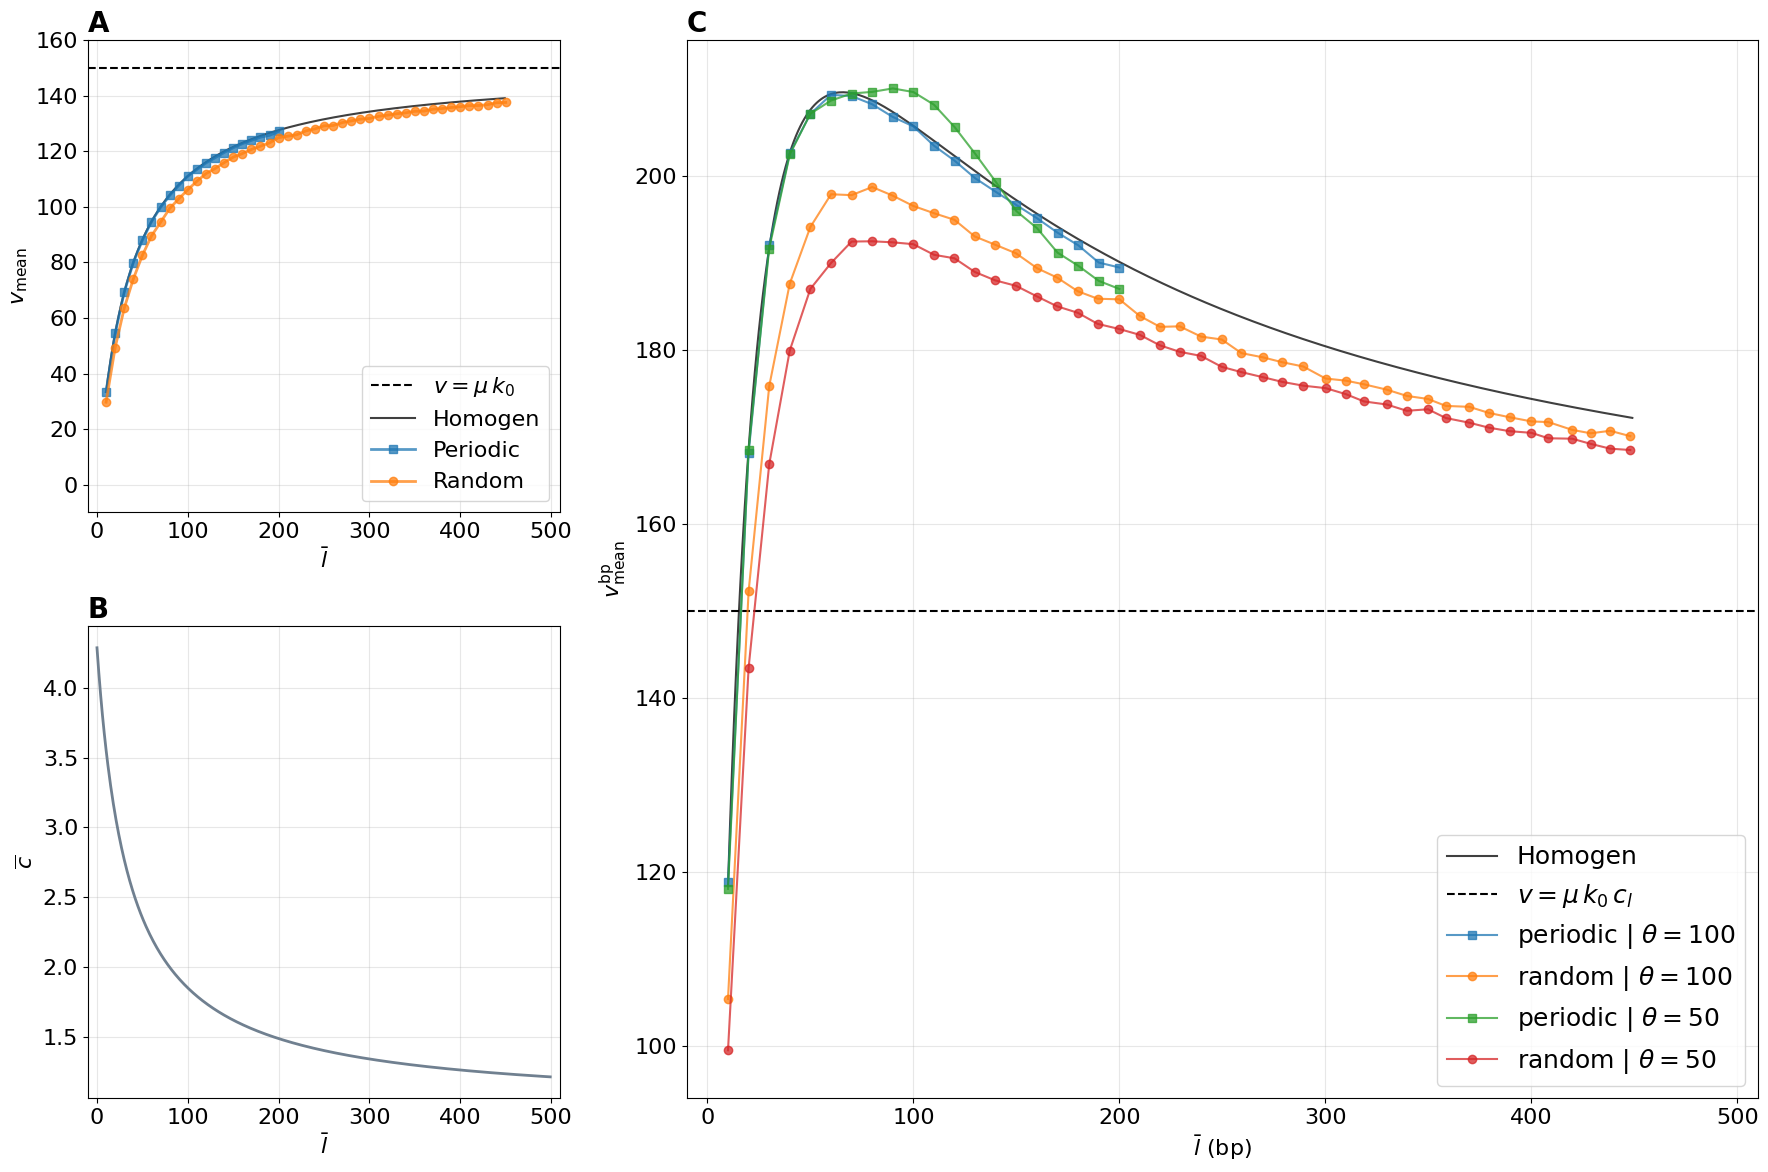

In [4]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import numpy as np
from pathlib import Path

# Taille de police UNIQUE pour toute la figure (titres, labels, ticks,
# legendes) : on garde exactement la même valeur que dans les figures
# individuelles, donc rien n'est redéfini case par case ci-dessous.
plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-08-27")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# DATA FRAME
# ─────────────────────────────────────────────

# Loading data
ARRAY_COLS = ["results", "results_mean", "alpha_mean_a"]

df_data = (
    pl.scan_parquet(paths)
    .select(cs.numeric() | cs.boolean() | cs.string()) # | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "mu", "theta", "alphad"])
)

COLUMNS = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

# Printing data
for col in COLUMNS:
    print(f"Unique values of {col} : {np.unique(df_data[col])}")


xlim_main = [-10, 510]
ylim_main = [-10, 160]


# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
mu    = 150
theta = 100
s_selected = 35

alphad_periodic = 0.0    # PERIODIC
alphad_homogen  = 1.0    # HOMOGEN (= periodic avec alphad = 1.0)
bpmin_random    = 0      # RANDOM

xlims=[-10, 510]
ylims=[0, 160]


# ─────────────────────────────────────────────
# FONCTIONS
# ─────────────────────────────────────────────

def density(l):
    return (150 + l) / (35 + l)

def compaction(l):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    return ((l * cl + s * cn) / (l + s))

def th_speed_sites(l, mu):
    s = 35
    return (mu * (l / (l+s)))

def th_speed_bps(l, mu):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    return (th_speed_sites(l, mu) * (l * cl + s * cn) / (l + s))


# ── FIGURE ─────
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 1],
    height_ratios=[1, 1]
)

ax1 = fig.add_subplot(gs[0, 0])      # Fig.1
ax2 = fig.add_subplot(gs[1, 0])      # Fig.2
ax3 = fig.add_subplot(gs[:, 1:])     # grand carré (2 colonnes × 2 lignes)

# ── FIG.1 : VITESSES EN SITE (v_mean vs l) ─────


mu = 150
theta = 100
s = 35
bpmin = 0
alphad = 0

df_data_0 = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu)    &
        (pl.col("theta") == theta) &
        (pl.col("bpmin") == bpmin) &
        (pl.col("alphad") == alphad) &
        (pl.col("s")     == s)
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)


df_periodic_0 = df_data_0.filter(
    pl.col("land") == "periodic"
)
df_random_0 = df_data_0.filter(
    pl.col("land") == "random"
)

ax1.axhline(mu, c="k", ls="--", label=r"$v=\mu\, k_0$")

l_homogen = np.arange(10,450,1)
v_homogen_sites = th_speed_sites(l_homogen, 150)
ax1.plot(l_homogen, v_homogen_sites, ls="-", alpha=0.75, label="Homogen", color="k")

l_periodic = df_periodic_0["l"].to_numpy()
v_periodic = df_periodic_0["v_mean"].to_numpy()
ax1.plot(l_periodic, v_periodic, ls="-", lw=2, alpha=0.75, marker="s", label="Periodic")

l_random = df_random_0["l"].to_numpy()
v_random = df_random_0["v_mean"].to_numpy()
ax1.plot(l_random, v_random, ls="-", lw=2, alpha=0.75, marker="o", label="Random")

ax1.set_xlabel(r"$\bar{l}$")
ax1.set_ylabel(r"$v_{\text{mean}}$")
ax1.set_xlim(xlim_main)
ax1.set_ylim(ylim_main)
ax1.legend(loc="best")
ax1.grid(True, alpha=0.30, which="both")


# ── FIG.2 : COMPACTION vs l_mean ───────────────
l_mean_curve = np.arange(0, 500, 1)
ax2.plot(l_mean_curve, density(l_mean_curve), ls="-", alpha=1, lw=2, color="slategray")
ax2.set_xlabel(r"$\bar{l}$")
ax2.set_ylabel(r"$\overline{c}$")
ax2.set_xlim(xlim_main)
ax2.grid(True, alpha=0.30)


# ── FIG.5.C ─────────────────────────────────────
mu      = 150
alphad  = 0.0
bpmin   = 0

df_figure_1 = df_data.filter(
    (pl.col("mu") == mu) &
    (pl.col("alphad") == alphad) &
    (pl.col("bpmin") == bpmin) 
)

lands   = np.unique(df_figure_1["land"].to_numpy())
thetas  = np.unique(df_figure_1["theta"].to_numpy())
thetas  = [100, 50]

l_homogen = np.arange(10,450,1)
v_homogen_bps = th_speed_bps(l_homogen, mu)
ax3.plot(l_homogen, v_homogen_bps, ls="-", alpha=0.75, label="Homogen", color="black")
ax3.axhline(mu, c="k", ls="--", label=r"$v = \mu\, k_0\, c_l$")

for theta in thetas:
    for land in lands :

        df_plot = df_figure_1.filter(
            (pl.col("theta") == theta) &
            (pl.col("land") == land)
        )

        l       = df_plot["l"].to_numpy()
        l_mean  = df_plot["l_mean"].to_numpy()
        vc_mean = df_plot["vc_mean"].to_numpy()

        if land == "periodic":
            label = rf"{land} | $\theta = {theta}$"
            ax3.plot(l, vc_mean, marker="s", ls="-", alpha=0.75, label=label) 
        if land == "random":
            label = rf"{land} | $\theta = {theta}$"
            ax3.plot(l_mean, vc_mean, marker="o", ls="-", alpha=0.75, label=label)  


ax3.set_xlim(xlim_main)
ax3.set_xlabel(r"$\bar{l}$ (bp)")
ax3.set_ylabel(r"$v_{\mathrm{mean}}^{\mathrm{bp}}$")
ax3.legend(loc="lower right", fontsize=18)
ax3.grid(True, alpha=0.30)



# ax3.axhline(mu, c="k", ls="--", label=r"$v = \mu * c_{l}$")

# l_homogen = np.arange(10,450,1)
# v_homogen_bps = th_speed_bps(l_homogen)
# ax3.plot(l_homogen, v_homogen_bps, ls="-", alpha=0.75, label="Homogen", color=color_homogen)

# for group in df_periodic_5c.partition_by("alphad", as_dict=False):
#     alphad = group["alphad"][0]
#     # l_mean = group["l_mean"].to_numpy()
#     l      = group["l"].to_numpy()
#     vc     = group[v_to_plot].to_numpy()
#     match  = np.isclose(alphad, alphads_target, atol=1e-6)
#     if np.any(match):
#         idx = int(np.argmax(match))   # position de cette variante dans alphads_target -> nuance associee
#         ax3.plot(l, vc, ls="-", lw=2, alpha=0.75, marker="s",
#                   label=rf"Periodic : $\alpha_{{d}} = {alphad:.2f}$", color=shades_periodic[idx])

# for group in df_random_5c.partition_by("bpmin", as_dict=False):
#     bpmin  = group["bpmin"][0]
#     l_mean = group["l"].to_numpy()
#     vc     = group[v_to_plot].to_numpy()
#     match  = np.isclose(bpmin, bpmins_target, atol=1e-6)
#     if np.any(match):
#         idx = int(np.argmax(match))   # position de cette variante dans bpmins_target -> nuance associee
#         ax3.plot(l_mean, vc, ls="-", lw=2, alpha=0.75, marker="o",
#                   label=rf"Random : $bp_{{\min}} = {bpmin}$", color=shades_random[idx])

# ax3.set_xlabel(r"$<l>$")
# ax3.set_ylabel(r"$v^{\text{bp}}_{\text{mean}}$")
# ax3.legend(loc="lower right")
# ax3.set_xlim(xlims)
# ax3.grid(True, alpha=0.30)


# ── TITLES ─────────────────────────────────────
for ax, letter in zip(
    [ax1, ax2, ax3],
    ["A", "B", "C"],
):
    ax.set_title(letter, loc="left", fontweight="bold", fontsize=20)

plt.tight_layout()
plt.savefig("fig5_final.png", bbox_inches="tight", dpi=300)
plt.show()

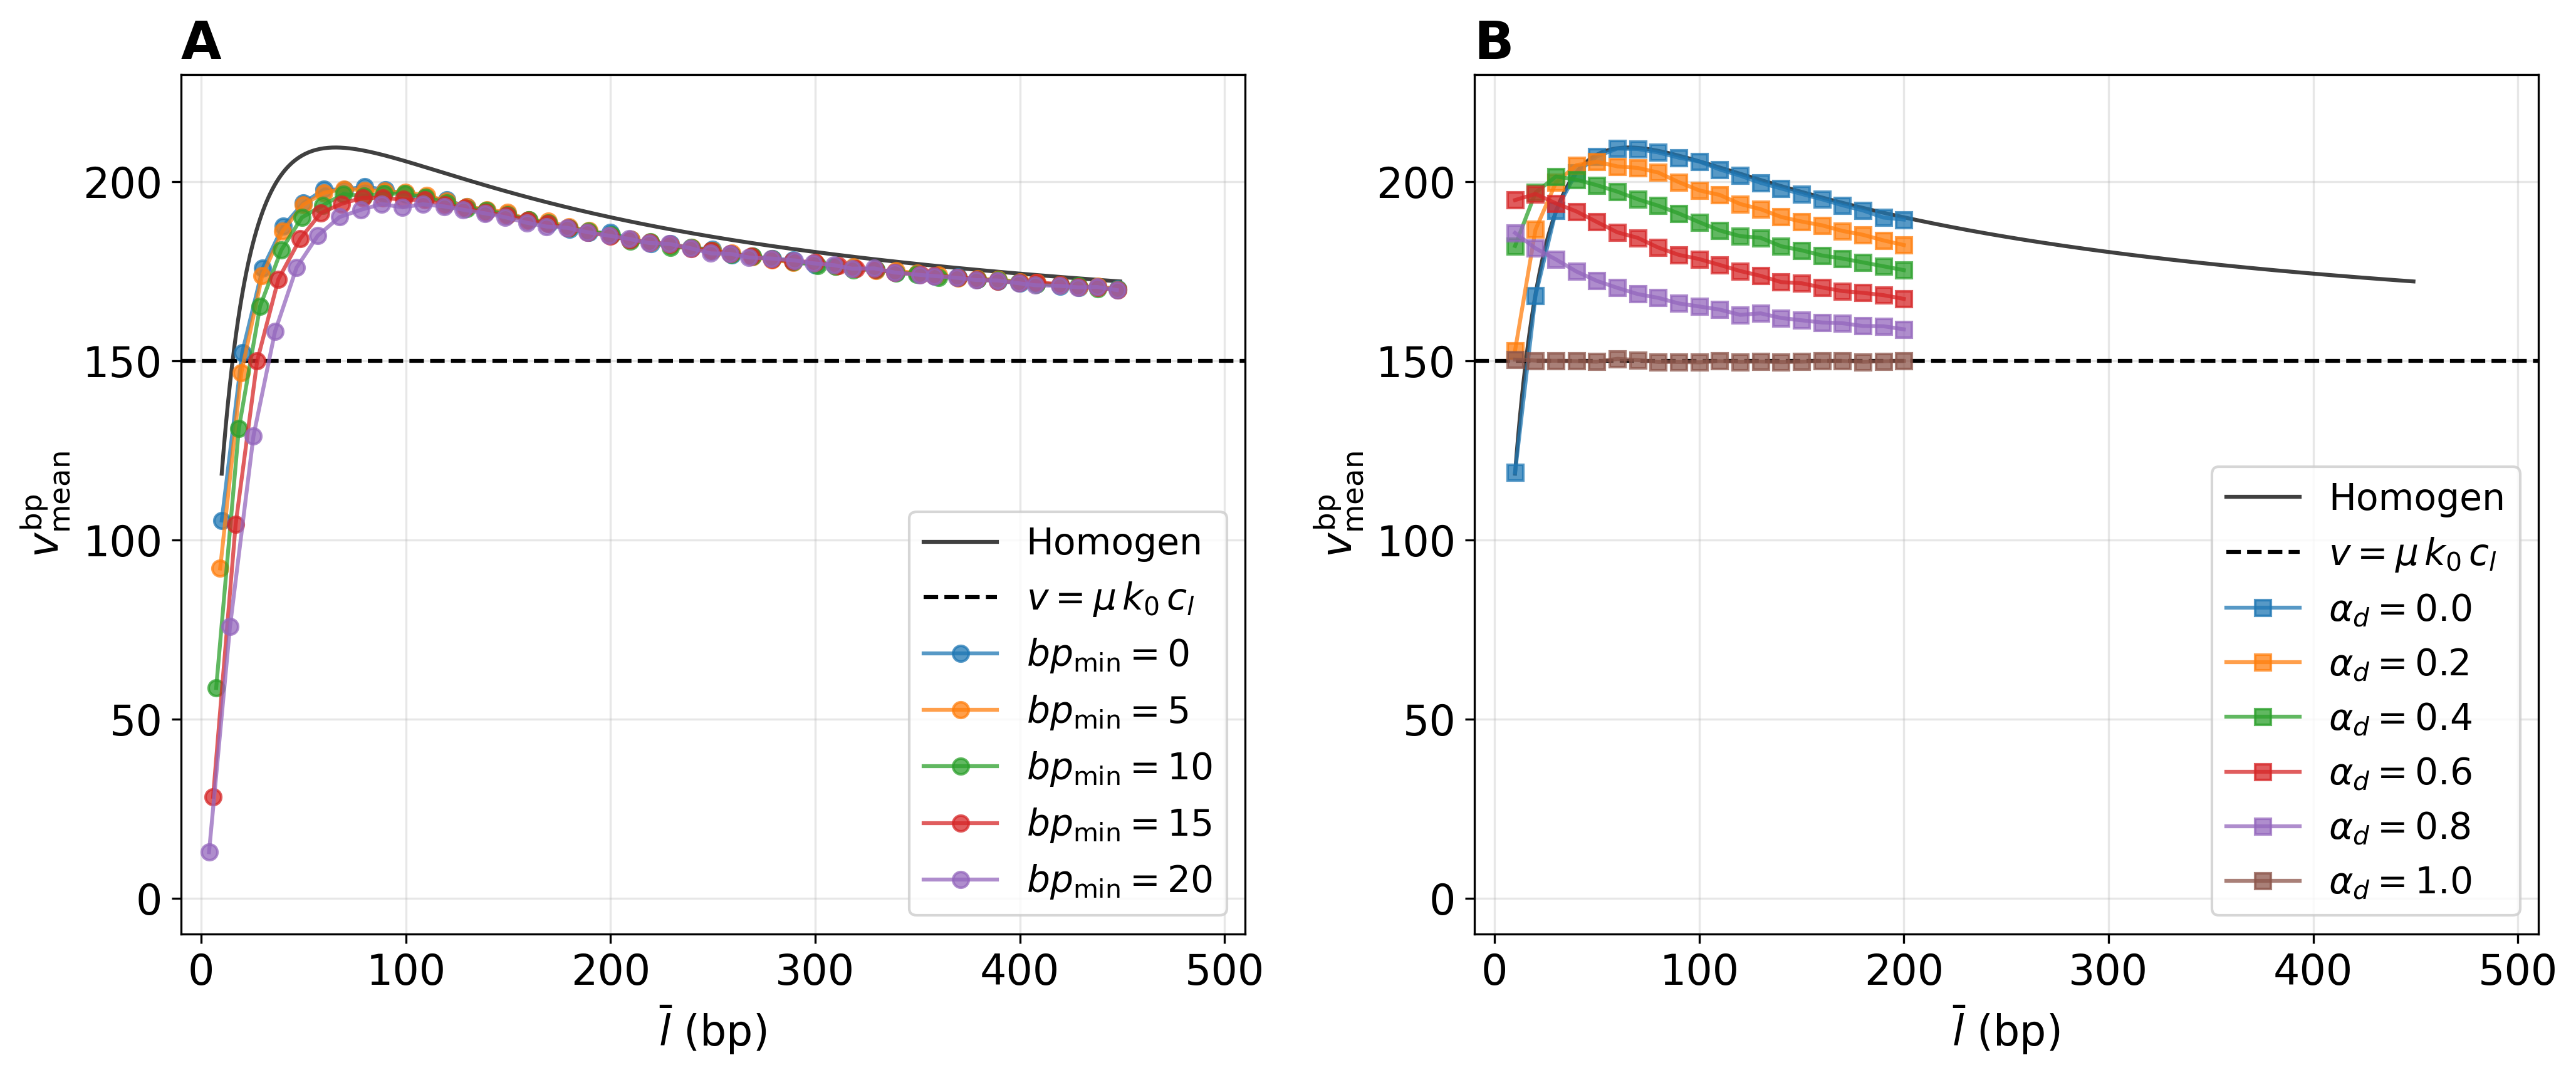

In [5]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    dpi=300
)

ylim_bis = [-10, 230]

# ─────────────────────────────────────────────
# A — mu = 500, alpha_d = 0
# ─────────────────────────────────────────────


mu = 150
theta = 100
bpmins = np.array([0, 5, 10, 15, 20])
land = "random"

df_random = df_data.filter(
    (pl.col("mu") == mu) &
    (pl.col("theta") == theta) &
    (pl.col("land") == land)
)


l_homogen = np.arange(10,450,1)
v_homogen_bps = th_speed_bps(l_homogen, mu)
ax1.plot(l_homogen, v_homogen_bps, ls="-", alpha=0.75, label="Homogen", color="black")
ax1.axhline(mu, c="k", ls="--", label=r"$v = \mu\, k_0\, c_l$")

for bpmin in bpmins:

    df_plot = df_random.filter(
        (pl.col("bpmin").is_close(bpmin))
    )

    l_mean  = df_plot["l_mean"].to_numpy()
    vc_mean = df_plot["vc_mean"].to_numpy()

    label = rf"$bp_{{\mathrm{{min}}}} = {bpmin}$"
    ax1.plot(l_mean, vc_mean, marker="o", ls="-", alpha=0.75, label=label)  


ax1.set_xlim(xlim_main)
ax1.set_ylim(ylim_bis)
ax1.set_xlabel(r"$\bar{l}$ (bp)")
ax1.set_ylabel(r"$v_{\mathrm{mean}}^{\mathrm{bp}}$")
ax1.legend(loc="lower right", fontsize=14)
ax1.grid(True, alpha=0.30)
ax1.set_title("A", loc="left", fontweight="bold", fontsize=20)


# ─────────────────────────────────────────────
# B — mu = 150, theta = 100
# ─────────────────────────────────────────────

mu = 150
theta = 100

alphads = np.array([
    0.0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0
])

land = "periodic"

df_periodic = df_data.filter(
    (pl.col("mu") == mu) &
    (pl.col("theta") == theta) &
    (pl.col("land") == land)
)

l_homogen = np.arange(10, 450, 1)
v_homogen_bps = th_speed_bps(l_homogen, mu)

ax2.plot(
    l_homogen,
    v_homogen_bps,
    ls="-",
    alpha=0.75,
    label="Homogen",
    color="black"
)

ax2.axhline(
    mu,
    c="k",
    ls="--",
    label=r"$v = \mu\, k_0\, c_l$"
)

for alphad in alphads:

    df_plot = df_periodic.filter(
        pl.col("alphad").is_close(alphad)
    )

    l       = df_plot["l"].to_numpy()
    vc_mean = df_plot["vc_mean"].to_numpy()

    label = rf"$\alpha_d = {alphad}$"

    ax2.plot(
        l,
        vc_mean,
        marker="s",
        ls="-",
        alpha=0.75,
        label=label
    )


ax2.set_xlim(xlim_main)
ax2.set_ylim(ylim_bis)

ax2.set_xlabel(r"$\bar{l}$ (bp)")
ax2.set_ylabel(r"$v_{\mathrm{mean}}^{\mathrm{bp}}$")

ax2.legend(
    loc="lower right", fontsize=14
)

ax2.grid(True, alpha=0.30)
ax2.set_title("B", loc="left", fontweight="bold", fontsize=20)



# ─────────────────────────────────────────────
# FINALISATION
# ─────────────────────────────────────────────

plt.tight_layout()
plt.show()

Unique values of algo : ['1S']
Unique values of fact : [False]
Unique values of mode : ['none']
Unique values of dstr : [ True]
Unique values of land : ['periodic' 'random']
Unique values of s : [35]
Unique values of l : [ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360
 370 380 390 400 410 420 430 440 450]
Unique values of bpmin : [ 0  5 10 15 20]
Unique values of mu : [150 500]
Unique values of theta : [ 50 100 300]
Unique values of alphaf : [1.]
Unique values of alphao : [0.]
Unique values of beta : [0.]
Unique values of rcapt : [2.]
Unique values of rrest : [2.]
Unique values of alphac : [1.]
Unique values of alphad : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Unique values of alphar : [0.]
Unique values of krel : [0.]
Unique values of Kp : [0.]
Unique values of Kz : [0.]


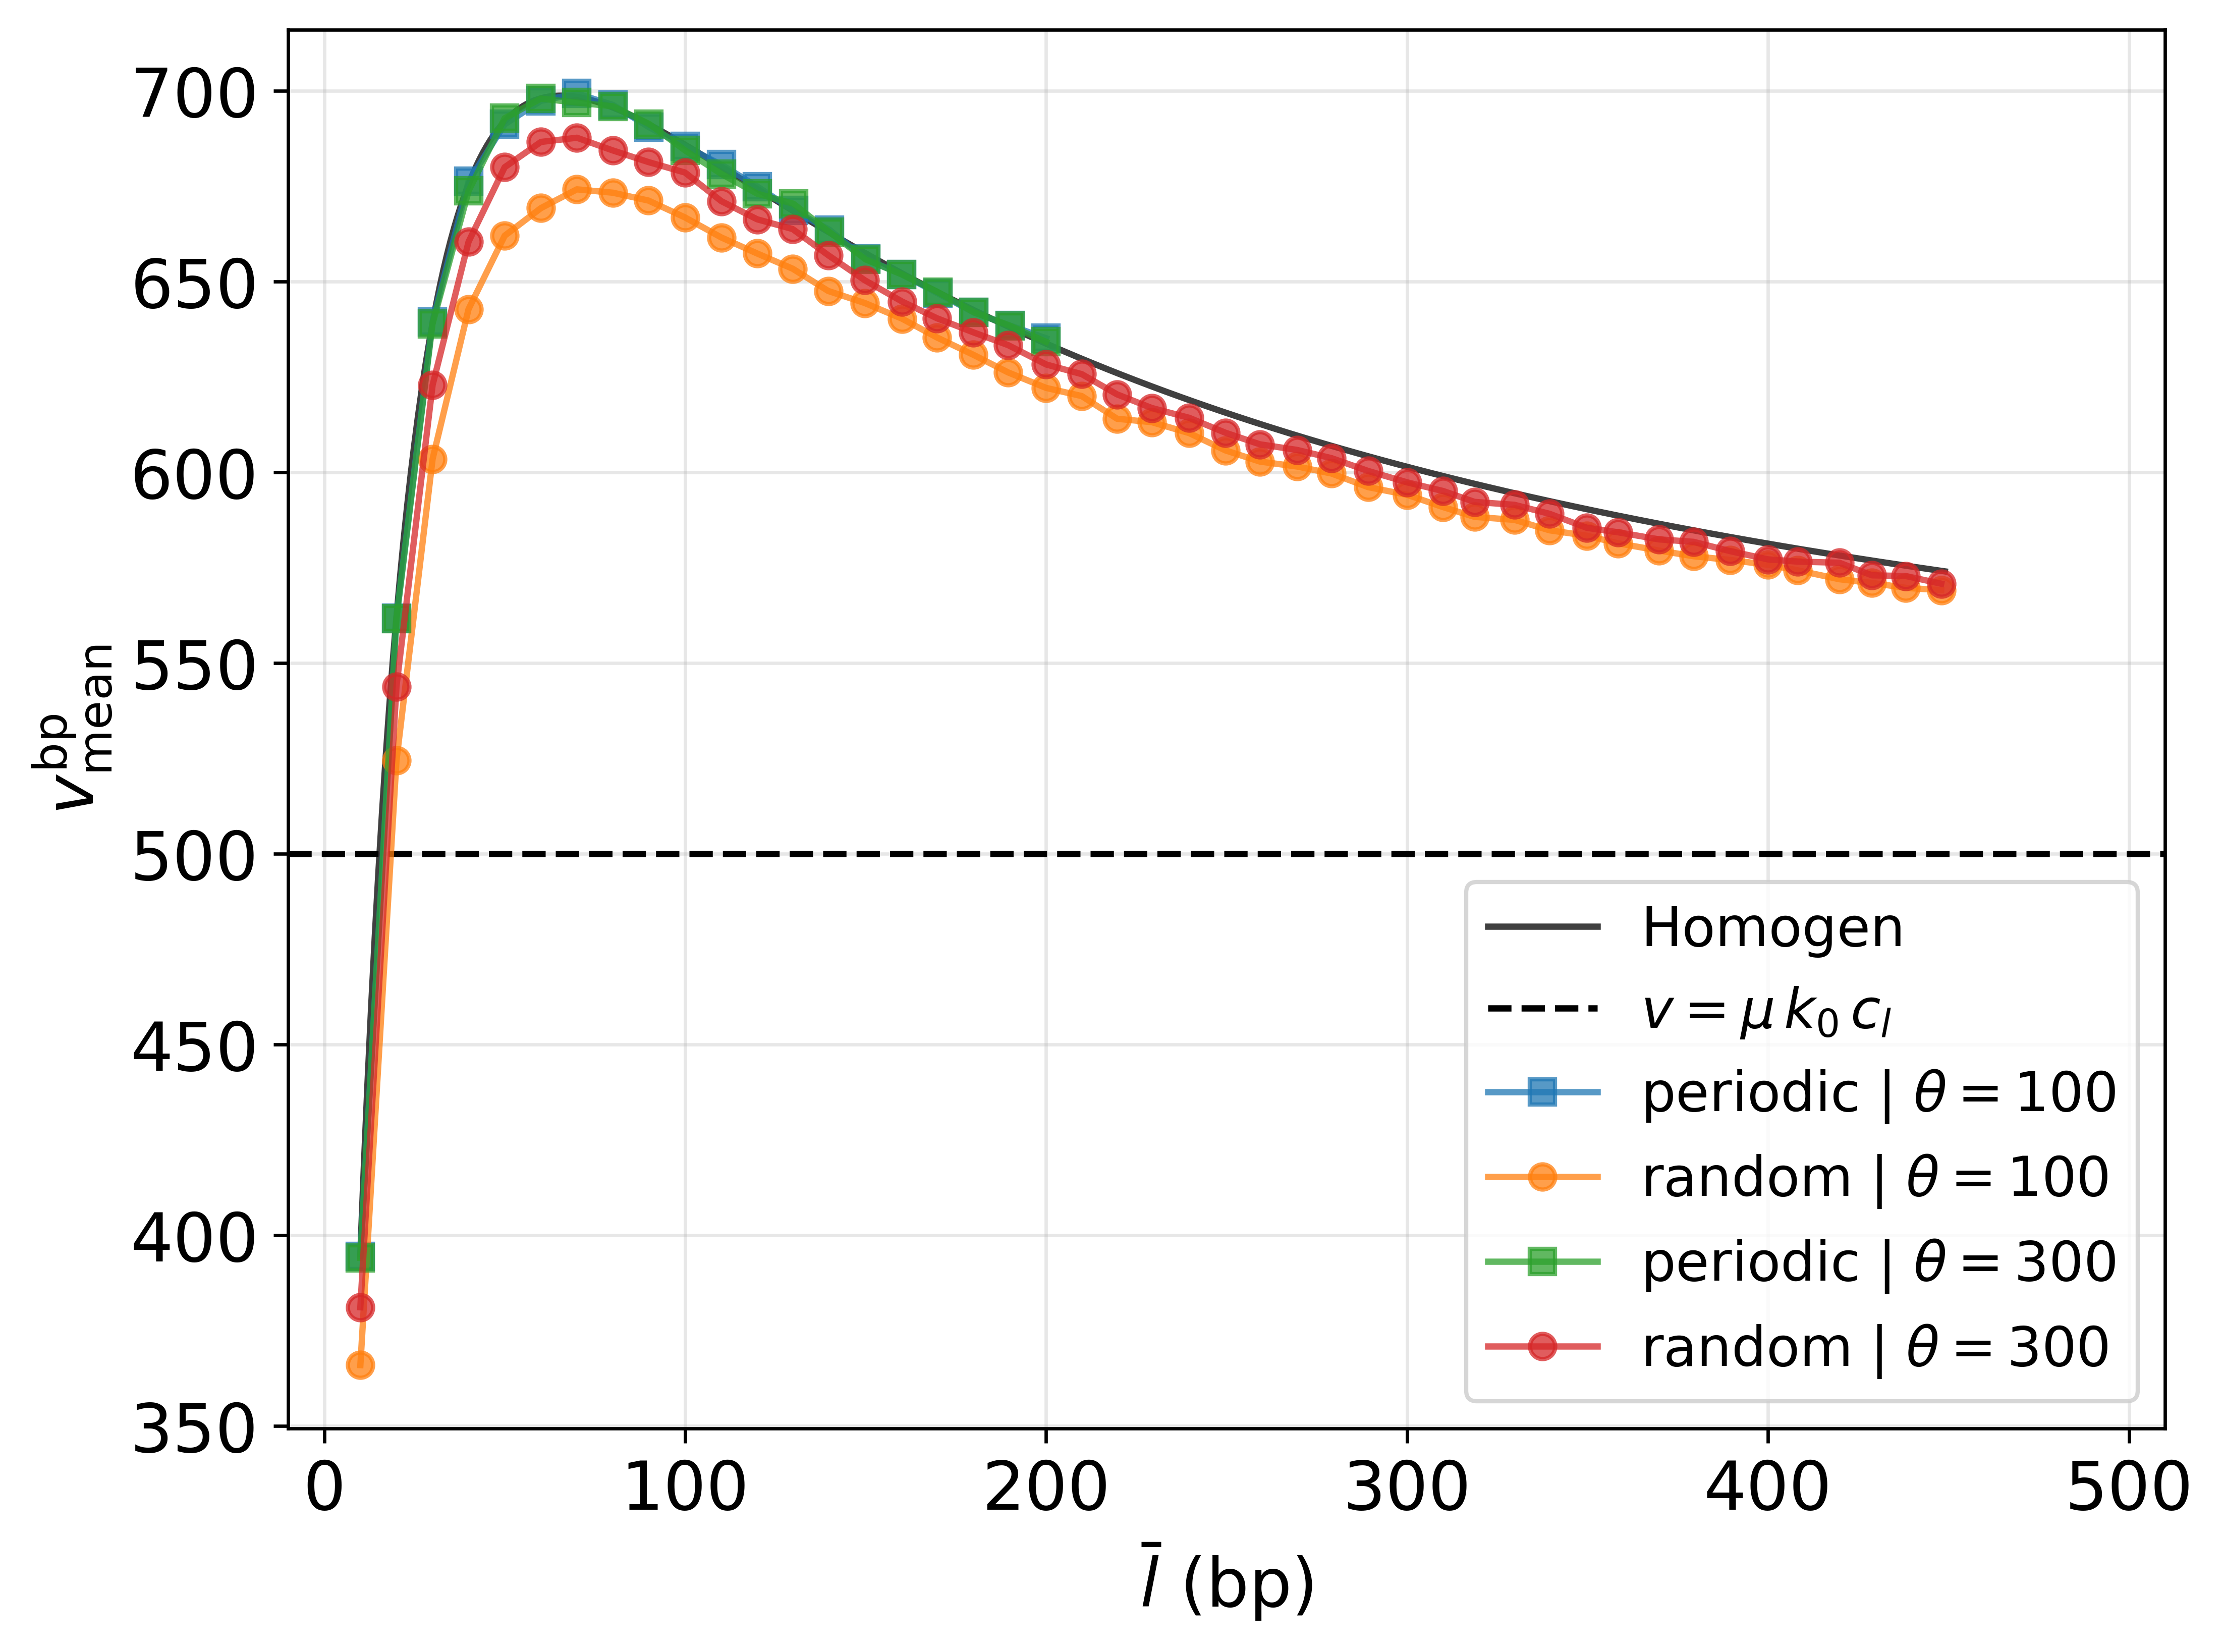

In [6]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import numpy as np
from pathlib import Path

# Taille de police UNIQUE pour toute la figure (titres, labels, ticks,
# legendes) : on garde exactement la même valeur que dans les figures
# individuelles, donc rien n'est redéfini case par case ci-dessous.
plt.rcParams['font.size'] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-08-27")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

# ─────────────────────────────────────────────
# DATA FRAME
# ─────────────────────────────────────────────

# Loading data
ARRAY_COLS = ["results", "results_mean", "alpha_mean_a"]

df_data = (
    pl.scan_parquet(paths)
    .select(cs.numeric() | cs.boolean() | cs.string()) # | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "mu", "theta", "alphad"])
)

COLUMNS = [
    'algo', 'fact', 'mode', 'dstr', 
    'land', 's', 'l', 'bpmin', 
    'mu', 'theta', 'alphaf', 
    'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 
    'alphar', 'krel', 'Kp', 'Kz'
]

# Printing data
for col in COLUMNS:
    print(f"Unique values of {col} : {np.unique(df_data[col])}")


xlim_main = [-10, 510]
ylim_main = [-10, 160]

alphad_periodic = 0.0    # PERIODIC
alphad_homogen  = 1.0    # HOMOGEN (= periodic avec alphad = 1.0)
bpmin_random    = 0      # RANDOM

xlims=[-10, 510]
ylims=[0, 160]


# ─────────────────────────────────────────────
# FONCTIONS
# ─────────────────────────────────────────────

def density(l):
    return (150 + l) / (35 + l)

def compaction(l):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    return ((l * cl + s * cn) / (l + s))

def th_speed_sites(l, mu):
    s = 35
    return (mu * (l / (l+s)))

def th_speed_bps(l, mu):
    s = 35
    cl = 1
    cn = 150/(10.5/0.3)
    return (th_speed_sites(l, mu) * (l * cl + s * cn) / (l + s))



# ── FIG.5.C ─────────────────────────────────────
plt.figure(figsize=(8,6), dpi=600)
mu      = 500
thetas  = [100, 300]
alphad  = 0.0
bpmin   = 0

df_figure_5 = df_data.filter(
    (pl.col("mu") == mu) &
    (pl.col("alphad") == alphad) &
    (pl.col("bpmin") == bpmin) 
)

lands   = np.unique(df_figure_5["land"].to_numpy())
thetas  = np.unique(df_figure_5["theta"].to_numpy())
thetas  = [100, 300]

l_homogen = np.arange(10,450,1)
v_homogen_bps = th_speed_bps(l_homogen, mu)
plt.plot(l_homogen, v_homogen_bps, ls="-", alpha=0.75, label="Homogen", color="black")
plt.axhline(mu, c="k", ls="--", label=r"$v = \mu\, k_0\, c_l$")

for theta in thetas:
    for land in lands :

        df_plot = df_figure_5.filter(
            (pl.col("theta") == theta) &
            (pl.col("land") == land)
        )

        l       = df_plot["l"].to_numpy()
        l_mean  = df_plot["l_mean"].to_numpy()
        vc_mean = df_plot["vc_mean"].to_numpy()

        if land == "periodic":
            label = rf"{land} | $\theta = {theta}$"
            plt.plot(l, vc_mean, marker="s", ls="-", alpha=0.75, label=label) 
        if land == "random":
            label = rf"{land} | $\theta = {theta}$"
            plt.plot(l_mean, vc_mean, marker="o", ls="-", alpha=0.75, label=label)  


plt.xlim(xlim_main)
plt.xlabel(r"$\bar{l}$ (bp)")
plt.ylabel(r"$v_{\mathrm{mean}}^{\mathrm{bp}}$")
plt.legend(loc="lower right", fontsize=13)
plt.grid(True, alpha=0.30)

# .